# GB1 AKA SPG1 

There are two datasets:

* SPG1_STRSG_Olson_2014: All doubles
* SPG1_STRSG_Wu_2016: All combos of a 4-mutant

FLIP calls this the GB1 dataset and calls the mutations V39, D40, G41 and V54, but I'm going to follow the PG convention, and use the PG mutation codes.

In [1]:
# 

# from app.helpers.sequence_util import VALID_AMINO_ACIDS
# from app.helpers.sequence_util import allele_set_to_seq_id
# with open('notebooks/jacob/SPG1_STRSG_Wu_2016_seqids.txt', 'w') as f:
#     for m1 in VALID_AMINO_ACIDS:
#         for m2 in VALID_AMINO_ACIDS:
#             for m3 in VALID_AMINO_ACIDS:
#                 for m4 in VALID_AMINO_ACIDS:
#                     allele_ids = []
#                     if m1 != 'V':
#                         allele_ids.append(f"V39{m1}")
#                     if m2 != 'D':
#                         allele_ids.append(f"D40{m2}")
#                     if m3 != 'G':
#                         allele_ids.append(f"G41{m3}")
#                     if m4 != 'V':
#                         allele_ids.append(f"V54{m4}")
#                     seq_id = allele_set_to_seq_id(set(allele_ids))
#                     f.write(f"{seq_id}\n")

In [ ]:
import os
from folde.data import DMS_METADATA_FILE, DMS_DIR
import pandas as pd

dms_file_path = os.path.join(DMS_DIR, f"SPG1_STRSG_Olson_2014.csv")
dms_df = pd.read_csv(dms_file_path)

with open('notebooks/jacob/SPG1_STRSG_Olson_2014_seqids.txt', 'w') as f:
    f.write('WT\n')
    for mutant in dms_df.mutant:
        f.write(f"{mutant.replace(':', '_')}\n")
dms_df

In [15]:
import os
from folde.data import DMS_METADATA_FILE, DMS_DIR
import pandas as pd

dms_file_path = os.path.join(DMS_DIR, f"SPG1_STRSG_Wu_2016.csv")
dms_df = pd.read_csv(dms_file_path)

with open('notebooks/jacob/SPG1_STRSG_Wu_2016_seqids.txt', 'w') as f:
    f.write('WT\n')
    for mutant in dms_df.mutant:
        f.write(f"{mutant.replace(':', '_')}\n")

# AAV

In [16]:
import pandas as pd
wt_aav_seq = 'MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLVLPGYKYLGPFNGLDKGEPVNEADAAALEHDKAYDRQLDSGDNPYLKYNHADAEFQERLKEDTSFGGNLGRAVFQAKKRVLEPLGLVEEPVKTAPGKKRPVEHSPVEPDSSSGTGKAGQQPARKRLNFGQTGDADSVPDPQPLGQPPAAPSGLGTNTMATGSGAPMADNNEGADGVGNSSGNWHCDSTWMGDRVITTSTRTWALPTYNNHLYKQISSQSGASNDNHYFGYSTPWGYFDFNRFHCHFSPRDWQRLINNNWGFRPKRLNFKLFNIQVKEVTQNDGTTTIANNLTSTVQVFTDSEYQLPYVLGSAHQGCLPPFPADVFMVPQYGYLTLNNGSQAVGRSSFYCLEYFPSQMLRTGNNFTFSYTFEDVPFHSSYAHSQSLDRLMNPLIDQYLYYLSRTNTPSGTTTQSRLQFSQAGASDIRDQSRNWLPGPCYRQQRVSKTSADNNNSEYSWTGATKYHLNGRDSLVNPGPAMASHKDDEEKFFPQSGVLIFGKQGSEKTNVDIEKVMITDEEEIRTTNPVATEQYGSVSTNLQRGNRQAATADVNTQGVLPGMVWQDRDVYLQGPIWAKIPHTDGHFHPSPLMGGFGLKHPPPQILIKNTPVPANPSTTFSAAKFASFITQYSTGQVSVEIEWELQKENSKRWNPEIQYTSNYNKSVNVDFTVDTNGVYSEPRPIGTRYLTRNL'
wt_aa_region = 'DEEEIRTTNPVATEQYGSVSTNLQRGNR'
aav_df = pd.read_csv('notebooks/jacob/flip-aav.csv')

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_34784/632742190.py:4: DtypeWarning: Columns (12,14,16,22) have mixed types. Specify dtype option on import or set low_memory=False.
  aav_df = pd.read_csv('notebooks/jacob/flip-aav.csv')


In [17]:
# Create the homolog lists.

# for fileidx in [0, 1, 2]:
#     with open(f'notebooks/jacob/aav_homologs_{fileidx}.fasta', 'w') as fasta_file:
#         with open(f'notebooks/jacob/aav_homolog_list_{fileidx}.txt', 'w') as list_file:
#             for ii, row in aav_df.iterrows():
#                 if int(ii) < fileidx * 100000 or int(ii) >= (fileidx + 1) * 100000:
#                     continue

#                 mutated_region = row.mutated_region
#                 mutated_seq = wt_aav_seq.replace(wt_aa_region, mutated_region)

#                 # Honor stop codons.
#                 mutated_seq = mutated_seq.split('*')[0]

#                 # Ignore that some are insertions.
#                 mutated_seq = mutated_seq.upper()

#                 hom_seq_id = f'HOM-AAV{ii:06d}'

#                 fasta_file.write(f'>{hom_seq_id}\n{mutated_seq}\n')
#                 list_file.write(f'{hom_seq_id}\n')


In [18]:
from Bio import SeqIO

aav_homolog_seq_to_id_map = {}

num_duplicates = 0

# Load in the aav_homolog fasta files.
for fileidx in [0, 1, 2]:
    with open(f'notebooks/jacob/aav_homologs_{fileidx}.fasta', 'r') as fasta_file:
        for record_idx, record in enumerate(SeqIO.parse(fasta_file, 'fasta')):
            seq = str(record.seq)
            if seq in aav_homolog_seq_to_id_map:
                num_duplicates += 1
                # print(f"Sequence {record.id} already in aav_homolog_seq_to_id_map under {aav_homolog_seq_to_id_map[seq]}\n{seq}")
                aav_homolog_seq_to_id_map[seq].append(record.id)
                continue

            aav_homolog_seq_to_id_map[seq] = [record.id]
            # if record_idx < 3:
            #     print(record.id, record.seq)
print(f'Number of duplicates: {num_duplicates}')

Number of duplicates: 230


In [19]:
# Create the homolog lists.

from collections import defaultdict

# Create a map from the mutated sequence to the mutation mask.
aav_homolog_seq_to_mutation_mask_map = defaultdict(list)
aav_mutation_mask_to_homolog_seq_map = {}

for ii, row in aav_df.iterrows():
    mutated_region = row.mutated_region
    mutated_seq = wt_aav_seq.replace(wt_aa_region, mutated_region)

    # Honor stop codons.
    mutated_seq = mutated_seq.split('*')[0]
    mutated_seq = mutated_seq.upper()
    
    assert mutated_seq in aav_homolog_seq_to_id_map, f"Mutated sequence {mutated_seq} not found in aav_homolog_seq_to_id_map"

    aav_homolog_seq_to_mutation_mask_map[mutated_seq].append(row.mutation_mask)
    aav_mutation_mask_to_homolog_seq_map[row.mutation_mask] = mutated_seq

    # if len(aav_homolog_seq_to_mutation_mask[mutated_seq]) > 1:
    #     print(f"Mutated sequence {mutated_seq} has multiple mutation masks: {aav_homolog_seq_to_mutation_mask[mutated_seq]}")

In [20]:
aav_mutation_mask_to_homolog_id_map = {}
for homolog_seq, mutation_mask_list in aav_homolog_seq_to_mutation_mask_map.items():
    assert homolog_seq in aav_homolog_seq_to_id_map, f"Homolog sequence {homolog_seq} not found in aav_homolog_seq_to_id_map"
    homolog_id_list = aav_homolog_seq_to_id_map[homolog_seq]
    assert len(homolog_id_list) == len(mutation_mask_list), f"Homolog sequence {homolog_seq} has {len(homolog_id_list)} ids but {len(mutation_mask_list)} mutation masks"
    for mutation_mask, homolog_id in zip(mutation_mask_list, homolog_id_list):
        aav_mutation_mask_to_homolog_id_map[mutation_mask] = homolog_id

In [21]:
aav_df['homolog_seq_id'] = aav_df.mutation_mask.apply(lambda x: aav_mutation_mask_to_homolog_id_map[x])
aav_df['homolog_seq'] = aav_df.mutation_mask.apply(lambda x: aav_mutation_mask_to_homolog_seq_map[x])
aav_df['DMS_score'] = aav_df.score

In [7]:
aav_df.to_csv('folde/data/FLIP-AAV_multimutant_dataset.csv', index=False)

In [26]:
aav_df

,mutation_mask,mutated_region,category,number_of_mutations,levenshtein_distance,binary_score,overarching_partition,score,full_aa_sequence,sampled_split,...,low_vs_high_split,low_vs_high_split_validation,mut_des_split,mut_des_split_validation,des_mut_split,des_mut_split_validation,reference_region,homolog_seq_id,homolog_seq,DMS_score
0,____________________________,DEEEIRTTNPVATEQYGSVSTNLQRGNR,wild_type,0,0,True,natural_partitions,-0.918194,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000000,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-0.918194
1,*____________________________,*DEEEIRTTNPVATEQYGSVSTNLQRGNR,stop,1,1,False,natural_partitions,-6.824780,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000001,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.824780
2,*___________________________,*EEEIRTTNPVATEQYGSVSTNLQRGNR,stop,1,1,False,natural_partitions,-6.500402,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000002,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.500402
3,A___________________________,AEEEIRTTNPVATEQYGSVSTNLQRGNR,single,1,1,True,natural_partitions,0.000887,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,test,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000003,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.000887
4,C___________________________,CEEEIRTTNPVATEQYGSVSTNLQRGNR,single,1,1,True,natural_partitions,0.337396,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000004,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.337396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284004,SA_MVIPVLKYGFQsYwNcHhPfKeVqPsTmQtDdCqWhHsE,SAEMVIPVLKYGFQsYwNcHhPfKeVqPsTmQtDdCqWhHsE,designed,41,38,False,natural_partitions,-5.352738,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV284004,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-5.352738
284005,SPGPQYAF__DPQImCqFmDsQwWmNmHmCsAdTnGqYlVfF,SPGPQYAFNPDPQImCqFmDsQwWmNmHmCsAdTnGqYlVfF,designed,40,38,False,natural_partitions,-5.114855,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,test,...,train,True,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV284005,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-5.114855
284006,EQSMNNVHEKS_SStLeIkWeWaCwThLwPtYmHcEmIrMgW,EQSMNNVHEKSASStLeIkWeWaCwThLwPtYmHcEmIrMgW,designed,41,39,False,natural_partitions,-5.087500,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV284006,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-5.087500
284007,EQSMNNVHEKSCSStLeIkWeWaCwThLwPtYmHcEmIrMgW,EQSMNNVHEKSCSStLeIkWeWaCwThLwPtYmHcEmIrMgW,designed,42,39,False,natural_partitions,-4.166373,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV284007,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-4.166373


<Axes: xlabel='levenshtein_distance', ylabel='score'>

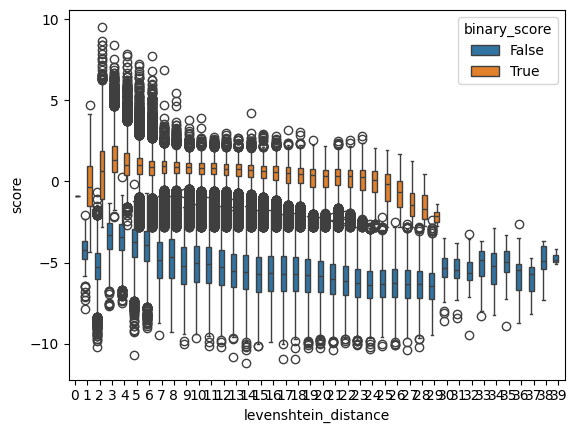

In [27]:
import seaborn as sns

sns.boxplot(data=aav_df,y='score', x='levenshtein_distance', hue='binary_score')
# aav_df.score.hist()

In [34]:
import numpy as np

np.log(2.5)

0.9162907318741551

In [41]:
np.exp(aav_df.score + 0.918193711)

0         1.000000
1         0.002721
2         0.003764
3         2.506985
4         3.509906
            ...   
284004    0.011860
284005    0.015046
284006    0.015463
284007    0.038845
284008    0.019801
Name: score, Length: 284009, dtype: float64

In [42]:
aav_df.groupby('binary_score').score.mean()

binary_score
False   -5.578146
True     0.644820
Name: score, dtype: float64

In [1]:
from folde.data import get_available_proteingym_datasets

get_available_proteingym_datasets('300m', '600m')

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423.0,False,9576.0,9576.0,...,A0A140D2T1_ZIKV_Sourisseau_growth_2019.csv,effect,1.0,mutant,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness
4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565.0,False,10715.0,10715.0,...,A0A2Z5U3Z0_9INFA_Doud_2016.csv,transformed_pref,1.0,mutant,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness
11,ADRB2_HUMAN_Jones_2020,ADRB2_HUMAN_Jones_2020.csv,ADRB2_HUMAN,Human,Homo sapiens,MGQPGNGSAFLLAPNGSHAPDHDVTQERDEVWVVGMGIVMSLIVLA...,413.0,False,7800.0,7800.0,...,ADRB2_HUMAN_Jones_2020.csv,0.625,1.0,mutant_id,ADRB2_HUMAN_theta_0.2.npy,ADRB2_HUMAN.pdb,1-413,0.1,NaN,Activity
14,AMIE_PSEAE_Wrenbeck_2017,AMIE_PSEAE_Wrenbeck_2017.csv,AMIE_PSEAE,Prokaryote,Pseudomonas aeruginosa,MRHGDISSSNDTVGVAVVNYKMPRLHTAAEVLDNARKIAEMIVGMK...,346.0,False,6227.0,6227.0,...,AMIE_PSEAE_Wrenbeck_2017.csv,isobutyramide_normalized_fitness,1.0,mutant,AMIE_PSEAE_theta_0.2.npy,AMIE_PSEAE.pdb,1-346,0.1,NaN,Activity
15,ANCSZ_Hobbs_2022,ANCSZ_Hobbs_2022.csv,ANCSZ,Eukaryote,Reconstructed ancestor,MADSANHLPYFYGSITREEAEDYLKQGGMSDGLFLLRQSLNSLGGY...,627.0,False,4670.0,4670.0,...,ANCSZ_Hobbs_2022.csv,DMS_value,1.0,mutant,ANCSZ_theta_0.2.npy,ANCSZ.pdb,1-627,1.0,NaN,Activity
21,BLAT_ECOLX_Firnberg_2014,BLAT_ECOLX_Firnberg_2014.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286.0,False,4783.0,4783.0,...,BLAT_ECOLX_Firnberg_2014.csv,linear,1.0,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
23,BLAT_ECOLX_Stiffler_2015,BLAT_ECOLX_Stiffler_2015.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286.0,False,4996.0,4996.0,...,BLAT_ECOLX_Stiffler_2015.csv,2500,1.0,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
26,C6KNH7_9INFA_Lee_2018,C6KNH7_9INFA_Lee_2018.csv,C6KNH7_9INFA,Virus,Influenza A virus (A/Perth/16/2009(H3N2)),MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,566.0,False,10754.0,10754.0,...,C6KNH7_9INFA_Lee_2018.csv,log_fitness_by_syn_mut_fitness,1.0,mutant,C6KNH7_9INFA_theta_0.01.npy,C6KNH7_9INFA.pdb,1-566,0.1,NaN,OrganismalFitness
31,CAS9_STRP1_Spencer_2017_positive,CAS9_STRP1_Spencer_2017_positive.csv,CAS9_STRP1,Prokaryote,Streptococcus pyogenes,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,1368.0,False,8117.0,8117.0,...,SPCAS9_Spencer_positive_2022.csv,Log2 Fold Change after Positive Selection,1.0,mutant,CAS9_STRP1_theta0.2_2023-08-07_b01.npy,CAS9_STRP1.pdb,1-1368,1.0,NaN,Activity
36,CBS_HUMAN_Sun_2020,CBS_HUMAN_Sun_2020.csv,CBS_HUMAN,Human,Homo sapiens,MPSETPQAEVGPTGCPHRSGPHSAKGSLEKGSPEDKEAKEPLWIRP...,551.0,False,7217.0,7217.0,...,NaN,score,1.0,mutant,CBS_HUMAN_theta0.2_2023-10-12_b08.npy,CBS_HUMAN.pdb,1-551,1.0,NaN,OrganismalFitness


# Consolidate embedding files.

In [ ]:
# Consolidate the embedding files.
import pandas as pd

aav_embeddings = pd.concat([
    pd.read_csv('folde/data/embeddings/FLIP-AAV_embedding_300m.csv'),
    pd.read_csv('~/Downloads/FLIP-AAV_embedding_wt-dms-300m.csv'),
])

In [ ]:
aav_embeddings.to_csv('folde/data/embeddings/FLIP-AAV_embedding_300m.csv', index=False)

In [4]:
aav_df[aav_df.homolog_seq_id.isin([
    "HOM-AAV000002",
    "HOM-AAV000129",
    "HOM-AAV000375",
    "HOM-AAV000387",
    "HOM-AAV000401",
    "HOM-AAV000427",
    "HOM-AAV000430",
    "HOM-AAV000449",
    "HOM-AAV000471",
    "HOM-AAV000561",
    "HOM-AAV000571",
    "HOM-AAV000572",
    "HOM-AAV000581",
    "HOM-AAV000693",
    "HOM-AAV001082",
    "HOM-AAV001131"])]

,mutation_mask,mutated_region,category,number_of_mutations,levenshtein_distance,binary_score,overarching_partition,score,full_aa_sequence,sampled_split,...,low_vs_high_split,low_vs_high_split_validation,mut_des_split,mut_des_split_validation,des_mut_split,des_mut_split_validation,reference_region,homolog_seq_id,homolog_seq,DMS_score
2,*___________________________,*EEEIRTTNPVATEQYGSVSTNLQRGNR,stop,1,1,False,natural_partitions,-6.500402,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000002,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.500402
129,____________*_______________,DEEEIRTTNPVA*EQYGSVSTNLQRGNR,stop,1,1,False,natural_partitions,-5.148055,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000129,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-5.148055
375,____________________________v,DEEEIRTTNPVATEQYGSVSTNLQRGNRv,single,1,1,True,natural_partitions,1.541731,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000375,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,1.541731
387,___________________________f_,DEEEIRTTNPVATEQYGSVSTNLQRGNfR,single,1,1,True,natural_partitions,1.159860,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000387,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,1.159860
401,___________________________w_,DEEEIRTTNPVATEQYGSVSTNLQRGNwR,single,1,1,False,natural_partitions,-2.049211,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,True,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000401,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-2.049211
427,__________________________t__,DEEEIRTTNPVATEQYGSVSTNLQRGtNR,single,1,1,True,natural_partitions,0.541580,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,test,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000427,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.541580
430,__________________________y__,DEEEIRTTNPVATEQYGSVSTNLQRGyNR,single,1,1,True,natural_partitions,-2.625796,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,train,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000430,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-2.625796
449,_________________________f___,DEEEIRTTNPVATEQYGSVSTNLQRfGNR,single,1,1,True,natural_partitions,1.139078,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,train,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000449,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,1.139078
471,________________________c____,DEEEIRTTNPVATEQYGSVSTNLQcRGNR,single,1,1,True,natural_partitions,0.656327,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,test,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000471,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.656327
561,_____________________i_______,DEEEIRTTNPVATEQYGSVSTiNLQRGNR,single,1,1,True,natural_partitions,-0.371840,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,test,...,test,NaN,train,NaN,test,NaN,DEEEIRTTNPVATEQYGSVSTNLQRGNR,HOM-AAV000561,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-0.371840


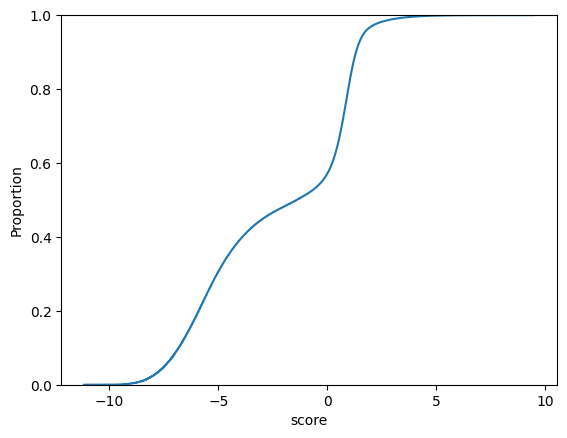

In [13]:
# Plot a cumulative distribution of the DMS scores.

import seaborn as sns
import matplotlib.pyplot as plt

sns.ecdfplot(aav_df.score)
plt.show()

In [14]:
(aav_df.score < 1.541731).mean()

0.9351605054769391

In [15]:
1/16

0.0625

In [ ]:
# Consolidate the embedding files.
import pandas as pd

spg1_olson_2014_embeddings = pd.concat([
    pd.read_csv('folde/data/embeddings/SPG1_STRSG_Olson_2014_embedding_300m.csv'),
    # pd.read_csv('notebooks/jacob/SPG1_STRSG_Olson_2014_embedding_wt-dms-300m.csv'),
])

In [5]:
spg1_olson_2014_embeddings.seq_id.duplicated().sum()

1045

In [6]:
spg1_olson_2014_embeddings = spg1_olson_2014_embeddings[~spg1_olson_2014_embeddings.seq_id.duplicated()]

In [ ]:
spg1_olson_2014_embeddings.to_csv('folde/data/embeddings/SPG1_STRSG_Olson_2014_embedding_300m.csv', index=False)

: 